# SVM + SMOTE

## I. Librerías

In [1]:
import numpy as np
import pandas as pd
import glob
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics, preprocessing
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')


## Data Loading

In [ ]:
import os
DATASETS = glob.glob(os.path.join("dataset", "*.csv"))
print(DATASETS) 


dfs = [pd.read_csv(path) for path in DATASETS]
df = pd.concat(dfs, ignore_index=True)

['C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Tuesday-WorkingHours.pcap_ISCX.csv']


## Clean Data + Normalization

In [3]:
# Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop('Label', axis=1)
y = df['Label']

# Replace infinite values with NaN, then drop affected rows
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# Normalise features to [0, 1] — required for SVM
scaler = preprocessing.MinMaxScaler()
X_norm = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


## Training / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm,
    y,
    train_size   = 0.8,
    random_state = 1234,
    shuffle      = True,
    stratify     = y
)


## Data Visualisation

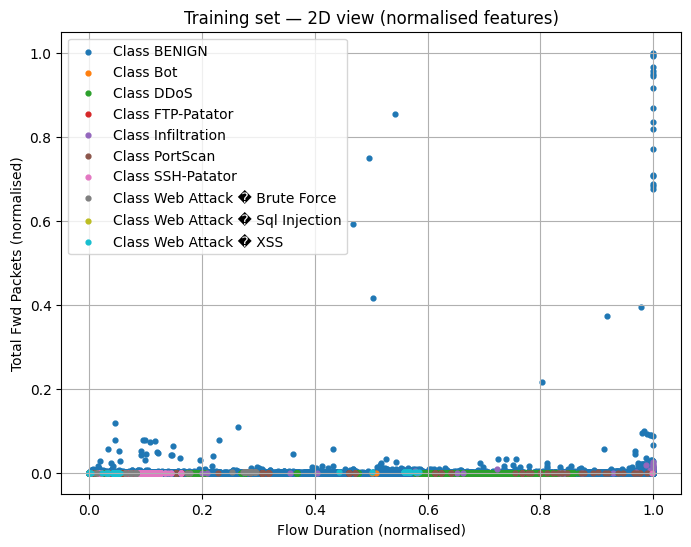

In [5]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

feat_x = 1
feat_y = 2

plt.figure(figsize=(8, 6))

y_arr = np.array(y_train)
for label in np.unique(y_arr):
    mask = (y_arr == label)
    plt.scatter(
        X_train.loc[mask, X_train.columns[feat_x]],
        X_train.loc[mask, X_train.columns[feat_y]],
        label=f'Class {label}',
        s=12
    )

plt.title('Training set — 2D view (normalised features)')
plt.xlabel(f'{X_train.columns[feat_x]} (normalised)')
plt.ylabel(f'{X_train.columns[feat_y]} (normalised)')
plt.legend()
plt.grid(True)
plt.show()


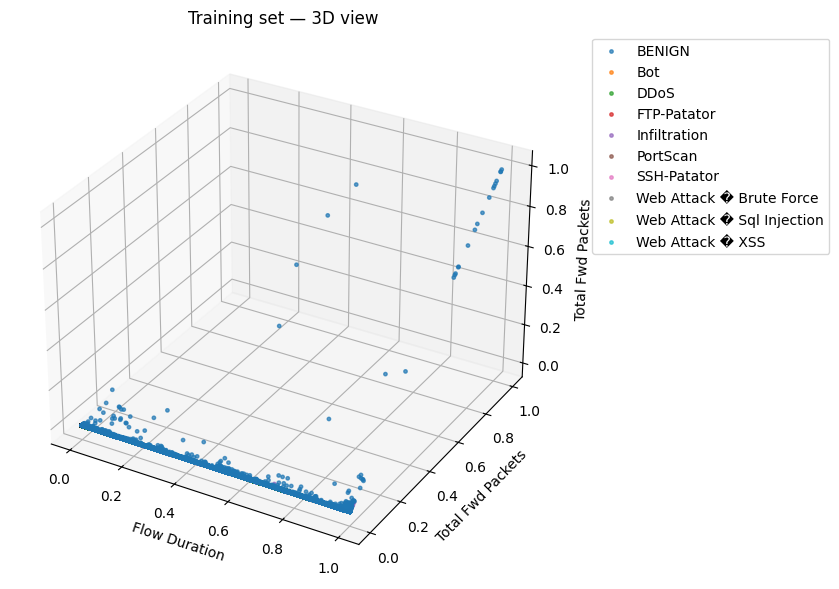

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

feat_x = 'Flow Duration'
feat_y = 'Total Fwd Packets'
feat_z = X_train.columns[3]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for label in np.unique(y_arr):
    mask = (y_arr == label)
    ax.scatter(
        X_train.loc[mask, feat_x],
        X_train.loc[mask, feat_y],
        X_train.loc[mask, feat_z],
        label=label,
        alpha=0.7,
        s=6
    )

ax.set_title('Training set — 3D view')
ax.set_xlabel(feat_x)
ax.set_ylabel(feat_y)
ax.set_zlabel(feat_z)

ax.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


## SMOTE

In [7]:
# ==============================
# BEFORE SMOTE
# ==============================
y_train_1d = np.ravel(y_train)
counts = Counter(y_train_1d)

print('Before Over Sampling:')
print(counts)
print()

# ==============================
# CREATE SAMPLING STRATEGY
# ==============================
cap = 10000  # maximum samples per minority class after oversampling
sampling_dict = {cls: cap for cls, c in counts.items() if c < cap}

print('Sampling strategy:', sampling_dict)
print()

# ==============================
# SAFE k_neighbors
# ==============================
# k must be at most (min_class_size - 1) to avoid SMOTE errors
min_class = min(counts.values())
k = min(3, max(1, min_class - 1))
print('Using k_neighbors =', k)

# ==============================
# APPLY SMOTE
# ==============================
sm1 = SMOTE(
    sampling_strategy=sampling_dict,
    random_state=2,
    k_neighbors=k
)

X_train_res, y_train_res = sm1.fit_resample(X_train, y_train_1d)

# ==============================
# AFTER SMOTE
# ==============================
print('\nAfter Over Sampling:')
print(Counter(y_train_res))
print()

print('After Over Sampling, the shape of train_X:', X_train_res.shape)
print('After Over Sampling, the shape of train_y:', y_train_res.shape)


Before Over Sampling:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 6348, 'SSH-Patator': 4717, 'Bot': 1565, 'Web Attack � Brute Force': 1205, 'Web Attack � XSS': 522, 'Infiltration': 29, 'Web Attack � Sql Injection': 17})

Sampling strategy: {'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000}

Using k_neighbors = 3

After Over Sampling:
Counter({'BENIGN': 1041725, 'PortScan': 127043, 'DDoS': 102420, 'FTP-Patator': 10000, 'SSH-Patator': 10000, 'Web Attack � Brute Force': 10000, 'Bot': 10000, 'Web Attack � XSS': 10000, 'Web Attack � Sql Injection': 10000, 'Infiltration': 10000})

After Over Sampling, the shape of train_X: (1341188, 78)
After Over Sampling, the shape of train_y: (1341188,)


## Hyperparameter Search

The full SMOTE-augmented set is too large for an exhaustive grid search with SVM. A stratified subsample is used for the search; the final model is trained on the complete set.

In [8]:
X_sample, _, y_sample, _ = train_test_split(
    X_train_res,
    y_train_res,
    train_size=15000,
    stratify=y_train_res,
    random_state=42
)

print('Subsample shape:', X_sample.shape)
print(pd.Series(y_sample).value_counts())


Subsample shape: (15000, 78)
BENIGN                        11650
PortScan                       1421
DDoS                           1145
SSH-Patator                     112
Web Attack � Sql Injection      112
Infiltration                    112
Web Attack � XSS                112
Bot                             112
FTP-Patator                     112
Web Attack � Brute Force        112
Name: count, dtype: int64


### Round 1 — Kernel selection (linear, RBF, polynomial)

In [ ]:
# Round 1 — RBF kernel: tune C and gamma
param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 5, 7, 10],
        'gamma': [0.01, 0.1, 0.5, 1]
    }
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=SVC(class_weight='balanced', random_state=123),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_sample, y_sample)

results_cv = pd.DataFrame(grid.cv_results_)
tabla_resultados = (
    results_cv
    .filter(regex='(param_|mean_test_score|std_test_score|rank_test_score)')
    .sort_values('mean_test_score', ascending=False)
    .head(8)
)

print('\n=== TOP RESULTS — GRID SEARCH (SVC RBF) ===\n')
print(tabla_resultados.to_string(index=False))
print('\nBest params:', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))


Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== TOP RESULTS — GRID SEARCH (SVC RBF) ===

 param_C  param_gamma param_kernel  mean_test_score  std_test_score  rank_test_score
    10.0          1.0          rbf         0.622884        0.025698                1
     7.0          1.0          rbf         0.577520        0.008565                2
     5.0          1.0          rbf         0.562431        0.009033                3
    10.0          0.5          rbf         0.560272        0.011010                4
     7.0          0.5          rbf         0.550543        0.008460                5
     5.0          0.5          rbf         0.541389        0.007613                6
     1.0          1.0          rbf         0.517487        0.005157                7
    10.0          0.1          rbf         0.499637        0.005554                8

Best params: {'C': 10, 'gamma': 1, 'kernel': 'rbf'}
Best CV score: 0.6229


In [ ]:
# Round 1 — linear kernel: tune C
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 3, 5, 7, 10]
    }
]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=SVC(class_weight='balanced', random_state=123),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_sample, y_sample)

results_cv = pd.DataFrame(grid.cv_results_)
tabla_resultados = (
    results_cv
    .filter(regex='(param_|mean_test_score|std_test_score|rank_test_score)')
    .sort_values('mean_test_score', ascending=False)
    .head(8)
)

print('\n=== TOP RESULTS — GRID SEARCH (SVC LINEAR) ===\n')
print(tabla_resultados.to_string(index=False))
print('\nBest params:', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))


Fitting 3 folds for each of 6 candidates, totalling 18 fits

=== TOP RESULTS — GRID SEARCH (SVC LINEAR) ===

 param_C param_kernel  mean_test_score  std_test_score  rank_test_score
    10.0       linear         0.549030        0.002564                1
     7.0       linear         0.535800        0.002048                2
     5.0       linear         0.520283        0.003270                3
     3.0       linear         0.504257        0.002776                4
     1.0       linear         0.462141        0.003344                5
     0.1       linear         0.370381        0.005680                6

Best params: {'C': 10, 'kernel': 'linear'}
Best CV score: 0.549


In [ ]:
# Round 1 — polynomial kernel: tune C, gamma, degree
param_grid = [
    {'kernel': ['poly'], 'C': [0.1, 1], 'gamma': [0.01, 0.1], 'degree': [2, 3]}
]

grid = GridSearchCV(
    estimator=SVC(class_weight='balanced', random_state=123),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=-1,
    cv=3,
    verbose=1,
    return_train_score=True
)

_ = grid.fit(X_sample, y_sample)

results = pd.DataFrame(grid.cv_results_)
top_results = (
    results.filter(regex='(param.*|mean_t|std_t)')
           .drop(columns='params')
           .sort_values('mean_test_score', ascending=False)
           .head(8)
)

print('Top results — polynomial kernel:')
print(top_results)
print('\nBest params:', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Top results — polynomial kernel:
   param_C  param_degree  param_gamma param_kernel  mean_test_score  \
5      1.0             2         0.10         poly         0.387787   
7      1.0             3         0.10         poly         0.387493   
3      0.1             3         0.10         poly         0.346105   
1      0.1             2         0.10         poly         0.326883   
4      1.0             2         0.01         poly         0.121121   
6      1.0             3         0.01         poly         0.017377   
2      0.1             3         0.01         poly         0.011064   
0      0.1             2         0.01         poly         0.011064   

   std_test_score  mean_train_score  std_train_score  
5        0.007779          0.388133         0.003353  
7        0.002897          0.388240         0.010740  
3        0.011503          0.346600         0.008126  
1        0.016994          0.328141         0.0

### Round 2 — Tune kernel RBF

In [ ]:

param_grid = [
    {
        'kernel': ['rbf'],
        'C':      [8, 10, 15, 20],
        'gamma':  [0.5, 1, 2, 5]
    }
]
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

grid = GridSearchCV(
    estimator=SVC(class_weight='balanced', random_state=123),
    param_grid=param_grid,
    scoring='f1_macro',
    n_jobs=-1,
    cv=cv,
    refit=True,
    verbose=1,
    return_train_score=True
)

grid.fit(X_sample, y_sample)

results_cv = pd.DataFrame(grid.cv_results_)
tabla_resultados = (
    results_cv
    .filter(regex='(param_|mean_test_score|std_test_score|rank_test_score)')
    .sort_values('mean_test_score', ascending=False)
    .head(8)
)

print('\n=== TOP RESULTS — GRID SEARCH (SVC RBF) ===\n')
print(tabla_resultados.to_string(index=False))
print('\nBest params:', grid.best_params_)
print('Best CV score:', round(grid.best_score_, 4))


## Final Model

In [ ]:
# SVM is computationally expensive; training on the full resampled set
# is often infeasible. The model is trained on the stratified subsample
# used during the search (15,000 samples, class-balanced via SMOTE + class_weight).
model_final = SVC(C=20, gamma=5, kernel='rbf', random_state=123, class_weight='balanced')
model_final.fit(X_sample, y_sample)


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Evaluation

### Train


 Accuracy train: 85.07 %

                             precision    recall  f1-score   support

                    BENIGN       1.00      0.82      0.90     11650
                       Bot       0.13      1.00      0.23       112
                      DDoS       0.73      1.00      0.84      1145
               FTP-Patator       0.65      1.00      0.79       112
              Infiltration       0.90      0.99      0.94       112
                  PortScan       0.75      1.00      0.86      1421
               SSH-Patator       0.27      0.99      0.43       112
  Web Attack � Brute Force       0.29      0.05      0.09       112
Web Attack � Sql Injection       0.64      0.67      0.66       112
          Web Attack � XSS       0.42      0.97      0.59       112

                  accuracy                           0.85     15000
                 macro avg       0.58      0.85      0.63     15000
              weighted avg       0.93      0.85      0.87     15000



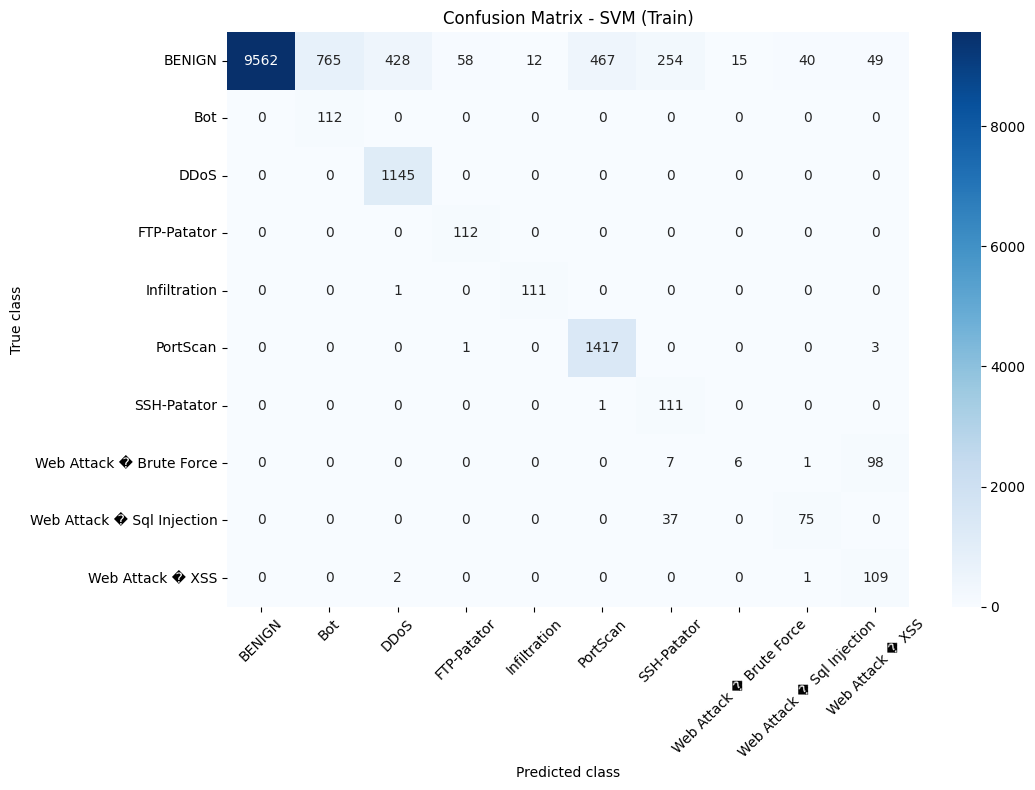

In [14]:
predictions_train = model_final.predict(X_sample)

print('\n Accuracy train: {:.2f} %'.format(100 * accuracy_score(y_sample, predictions_train)))
print('\n', classification_report(y_sample, predictions_train))

labels = sorted(np.unique(y_sample))
cm = confusion_matrix(y_sample, predictions_train, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted class'); plt.ylabel('True class')
plt.title('Confusion Matrix - SVM (Train)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


### Test

Accuracy test: 85.42 %

                             precision    recall  f1-score   support

                    BENIGN       1.00      0.82      0.90    260431
                       Bot       0.02      0.99      0.04       391
                      DDoS       0.72      1.00      0.84     25605
               FTP-Patator       0.51      0.98      0.68      1587
              Infiltration       0.02      0.71      0.03         7
                  PortScan       0.75      1.00      0.86     31761
               SSH-Patator       0.18      0.99      0.31      1180
  Web Attack � Brute Force       0.05      0.08      0.06       302
Web Attack � Sql Injection       0.00      0.25      0.00         4
          Web Attack � XSS       0.07      0.98      0.13       130

                  accuracy                           0.85    321398
                 macro avg       0.33      0.78      0.39    321398
              weighted avg       0.95      0.85      0.89    321398



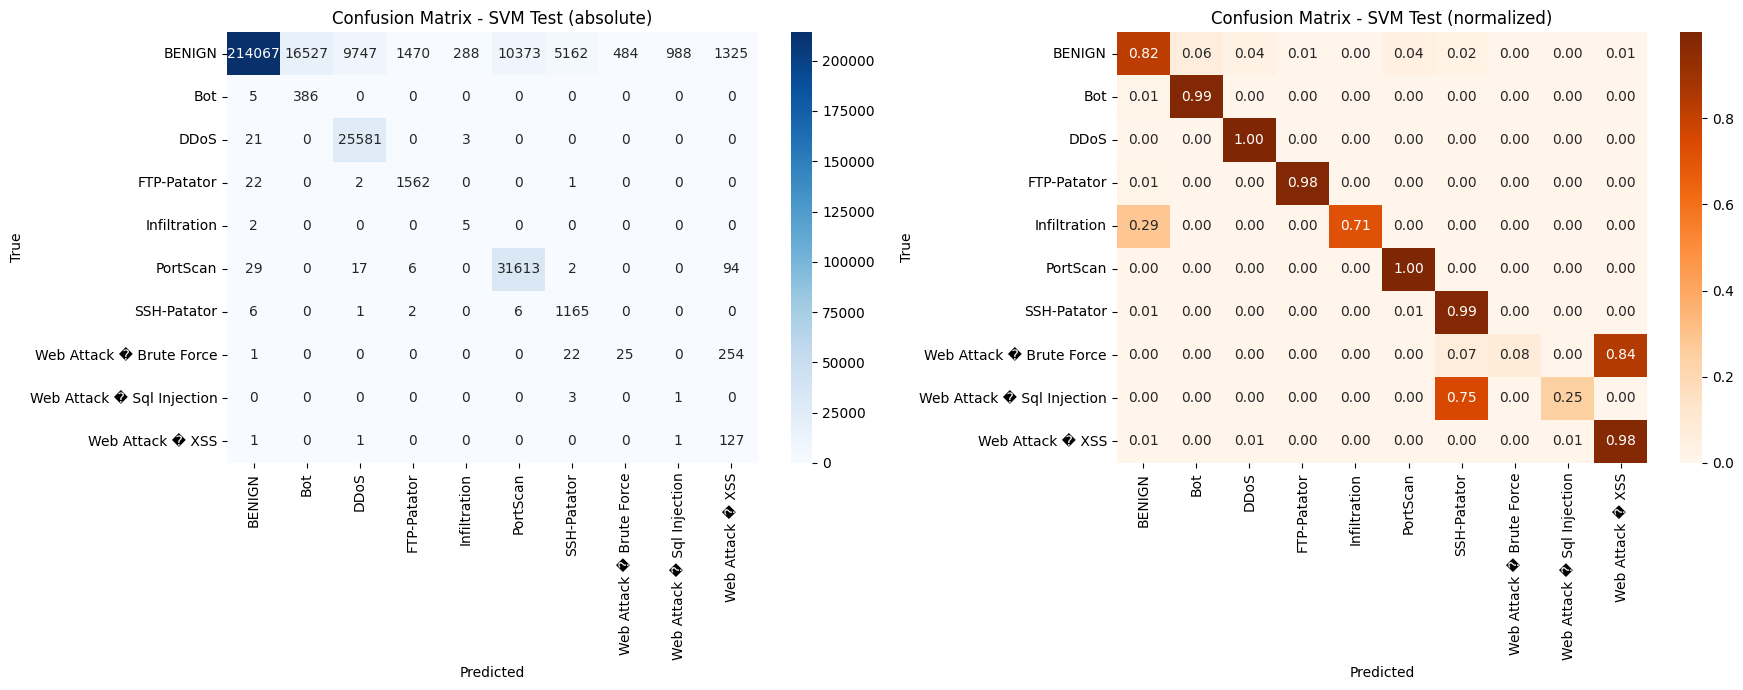

In [15]:
pred_test = model_final.predict(X_test)

print('Accuracy test: {:.2f} %'.format(100 * accuracy_score(y_test, pred_test)))
print('\n', classification_report(y_test, pred_test))

labels = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, pred_test, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix - SVM Test (absolute)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix - SVM Test (normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout(); plt.show()


## Feature Importance

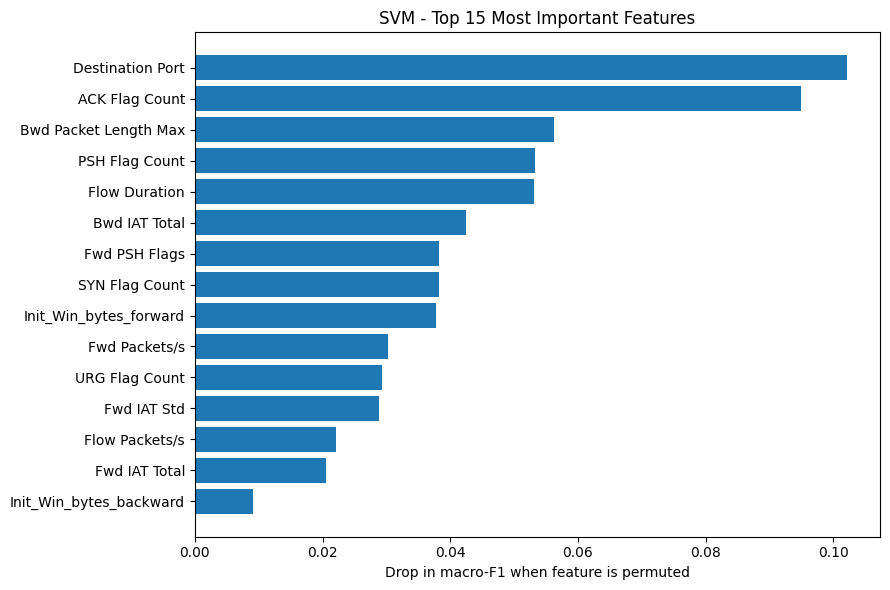

                Feature  Importance
       Destination Port    0.102224
         ACK Flag Count    0.094959
  Bwd Packet Length Max    0.056291
         PSH Flag Count    0.053322
          Flow Duration    0.053193
          Bwd IAT Total    0.042528
          Fwd PSH Flags    0.038279
         SYN Flag Count    0.038279
 Init_Win_bytes_forward    0.037804
          Fwd Packets/s    0.030264
         URG Flag Count    0.029392
            Fwd IAT Std    0.028900
         Flow Packets/s    0.022051
          Fwd IAT Total    0.020494
Init_Win_bytes_backward    0.009066
            Bwd IAT Std    0.007781
           Flow IAT Max    0.007613
     Packet Length Mean    0.003078
    Average Packet Size    0.002901
      Max Packet Length    0.002242
                Feature  Importance
       Destination Port    0.102224
         ACK Flag Count    0.094959
  Bwd Packet Length Max    0.056291
         PSH Flag Count    0.053322
          Flow Duration    0.053193
          Bwd IAT Total    0

In [16]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Use a small subset of the test set — permutation importance doesn't need all of it
X_test_small, _, y_test_small, _ = train_test_split(
    X_test, y_test, train_size=500, stratify=y_test, random_state=42
)

result = permutation_importance(
    model_final, X_test_small, y_test_small,
    n_repeats=3,        # reduced from 5
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'
)

imp_df = pd.DataFrame({
    'Feature': X_test_small.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)

top_n = 15
imp_top = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(9, 6))
plt.barh(imp_top['Feature'], imp_top['Importance'])
plt.xlabel('Drop in macro-F1 when feature is permuted')
plt.title(f'SVM - Top {top_n} Most Important Features')
plt.tight_layout(); plt.show()

print(imp_df.head(20).to_string(index=False))
print(imp_df.head(20).to_string(index=False))
